In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import colormaps as cmaps

## FPC

In [2]:
base_PFT_FPC = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_01_29_baseline_run/baseline_withfire/output/fpc.nc").FPC[-1][1:]
base_PFT_FPC['pft'] = base_PFT_FPC['pft'] - 1
base_PFT_FPC

DM_PFT_FPC = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_04_23_global_droughtmort_new/withfire/output/fpc.nc").FPC[-1][1:]
DM_PFT_FPC['pft'] = DM_PFT_FPC['pft'] - 1
DM_PFT_FPC

<xarray.DataArray 'FPC' (pft: 11, lat: 1397, lon: 3600)> Size: 221MB
[55321200 values with dtype=float32]
Coordinates:
  * pft      (pft) int32 44B 1 2 3 4 5 6 7 8 9 10 11
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
    time     object 8B 2019-12-16 00:00:00
Attributes:
    standard_name:  FPC
    long_name:      foliage projected cover

## Mortality

In [3]:
DM_PFT_mort = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_04_23_global_droughtmort_new/withfire/output/pft_mort_yearly_sum.nc").mortality
base_PFT_mort = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_01_29_baseline_run/baseline_withfire/output/pft_mort_yearly_sum.nc").mortality
base_PFT_mort

<xarray.DataArray 'mortality' (time: 20, pft: 11, lat: 1397, lon: 3600)> Size: 4GB
[1106424000 values with dtype=float32]
Coordinates:
  * time     (time) object 160B 2000-01-01 00:00:00 ... 2019-01-01 00:00:00
  * pft      (pft) int32 44B 1 2 3 4 5 6 7 8 9 10 11
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
Attributes:
    units:          1/month
    standard_name:  mortality
    long_name:      Monthly mortality

In [4]:
DM_PFT_mort_mean = DM_PFT_mort.mean("time")
base_PFT_mort_mean = base_PFT_mort.mean("time")

In [5]:
DM_mort_total = (DM_PFT_FPC * DM_PFT_mort_mean).sum("pft")
base_mort_total = (base_PFT_FPC * base_PFT_mort_mean).sum("pft")

## GPP

In [6]:
base_PFT_GPP = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_01_29_baseline_run/baseline_withfire/output/mgpp.nc").GPP.sel(time = slice("2000","2019")).resample(time = "YS").sum()
DM_PFT_GPP = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_04_23_global_droughtmort_new/withfire/output/mgpp.nc").GPP.sel(time = slice("2000","2019")).resample(time = "YS").sum()

In [7]:
DM_PFT_GPP_mean = DM_PFT_GPP.mean("time")
base_PFT_GPP_mean = base_PFT_GPP.mean("time")

## Latent heat

In [8]:
base_LE = xr.open_dataset("/projects/prjs2023/chapter3/base_LE_2000_2019.nc").__xarray_dataarray_variable__
DM_LE = xr.open_dataset("/projects/prjs2023/chapter3/DM_LE_2000_2019.nc").__xarray_dataarray_variable__

In [9]:
base_LE_mean = base_LE.mean("time")
DM_LE_mean = DM_LE.mean("time")
DM_LE_mean

<xarray.DataArray '__xarray_dataarray_variable__' (lat: 1397, lon: 3600)> Size: 40MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(1397, 3600))
Coordinates:
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
Attributes:
    units:          W m-2
    standard_name:  time
    long_name:      Latent heat flux
    bounds:         time_bnds
    axis:           T

## Plotting

In [10]:
lsm = xr.open_dataset("/projects/prjs2023/chapter3/remapped_masks/land-sea-mask_01deg_shifted.nc").lsm
lsm

<xarray.DataArray 'lsm' (time: 1, lat: 1800, lon: 3600)> Size: 52MB
[6480000 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 8B 2023-01-01
  * lat      (lat) float64 14kB -89.95 -89.85 -89.75 ... 89.75 89.85 89.95
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
Attributes:
    standard_name:  land_binary_mask
    long_name:      Land-sea mask
    units:          (0 - 1)

/scratch-local/77370/ipykernel_3308912/501173730.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_continuous = plt.cm.get_cmap(cmap)


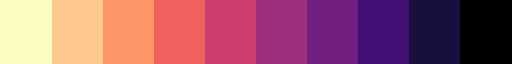

In [11]:
def create_discrete_colormap(cmap, num_colors):
    cmap_continuous = plt.cm.get_cmap(cmap)
    colors_continuous = cmap_continuous(np.linspace(0, 1, num_colors))  # Adjusted range, excluding white
    cmap_discrete = plt.matplotlib.colors.ListedColormap(colors_continuous)
    return cmap_discrete

# Example usage:
cmap_discrete = create_discrete_colormap("magma_r", 10)
cmap_discrete

In [12]:
# -----------------------------------
# Colormaps and scales
# -----------------------------------
gpp_cmap = create_discrete_colormap(cmaps.speed, 10)
gpp_vmin = 0
gpp_vmax = 5000

mort_cmap = create_discrete_colormap("YlOrRd", 7)
mort_vmin = 0
mort_vmax = 0.07

le_cmap = create_discrete_colormap(cmaps.deep, 10)
le_vmin = 0
le_vmax = 100

/scratch-local/77370/ipykernel_3308912/501173730.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_continuous = plt.cm.get_cmap(cmap)


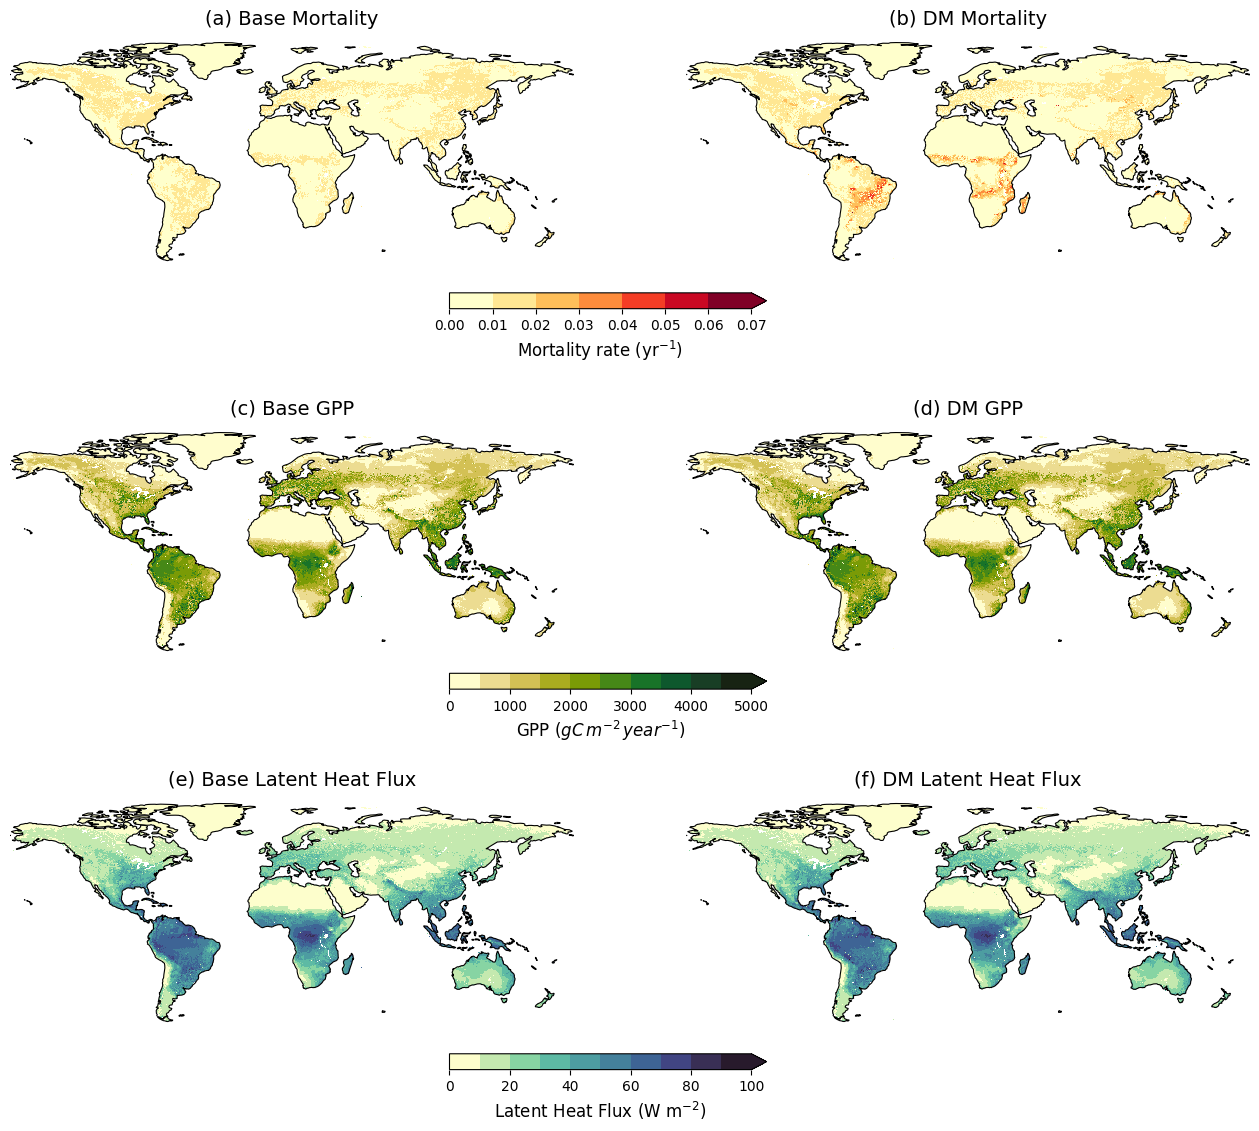

In [13]:


# -----------------------------------
# Align mask
# -----------------------------------
lsm_gpp = lsm.interp_like(base_PFT_GPP_mean)
lsm_mort = lsm.interp_like(base_mort_total)
lsm_le = lsm.interp_like(base_LE_mean)

# -----------------------------------
# Apply masks
# -----------------------------------
veg_mask = base_PFT_FPC[0:8].sum("pft") > 0.01

# GPP
base_gpp = (
    base_PFT_GPP_mean
    .where(lsm_gpp > 0.5)
)

DM_gpp = (
    DM_PFT_GPP_mean
    .where(lsm_gpp > 0.5)
)

# Mortality
base_mort = (
    base_mort_total
    .where(lsm_mort > 0.5)
)

DM_mort = (
    DM_mort_total
    .where(lsm_mort > 0.5)
)

# Latent heat
base_LE = (
    base_LE_mean
    .where(lsm_le > 0.5)
)

DM_LE = (
    DM_LE_mean
    .where(lsm_le > 0.5)
)

# -----------------------------------
# Remove Antarctica
# -----------------------------------
base_gpp  = base_gpp.where(base_gpp.lat > -60)
DM_gpp    = DM_gpp.where(DM_gpp.lat > -60)

base_mort = base_mort.where(base_mort.lat > -60)
DM_mort   = DM_mort.where(DM_mort.lat > -60)

# -----------------------------------
# Projection
# -----------------------------------
proj = ccrs.PlateCarree(central_longitude=11)

# -----------------------------------
# Figure and axes
# -----------------------------------
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(16, 14),
    subplot_kw={"projection": proj}
)



# ===================================
# TOP LEFT: Base GPP
# ===================================
im_gpp = base_gpp.plot(
    ax=axes[1, 0],
    transform=ccrs.PlateCarree(),
    cmap=gpp_cmap,
    vmin=gpp_vmin,
    vmax=gpp_vmax,
    extend="max",
    add_colorbar=False
)

axes[1, 0].coastlines(linewidth=0.8)
axes[1, 0].set_title("(c) Base GPP", fontsize=14)

# ===================================
# TOP RIGHT: DM GPP
# ===================================
DM_gpp.plot(
    ax=axes[1, 1],
    transform=ccrs.PlateCarree(),
    cmap=gpp_cmap,
    vmin=gpp_vmin,
    vmax=gpp_vmax,
    extend="max",
    add_colorbar=False
)

axes[1, 1].coastlines(linewidth=0.8)
axes[1, 1].set_title("(d) DM GPP", fontsize=14)

# ===================================
# BOTTOM LEFT: Base Mortality
# ===================================
im_mort = base_mort.plot(
    ax=axes[0, 0],
    transform=ccrs.PlateCarree(),
    cmap=mort_cmap,
    vmin=mort_vmin,
    vmax=mort_vmax,
    extend="max",
    add_colorbar=False
)

axes[0, 0].coastlines(linewidth=0.8)
axes[0, 0].set_title("(a) Base Mortality", fontsize=14)

# ===================================
# BOTTOM RIGHT: DM Mortality
# ===================================
DM_mort.plot(
    ax=axes[0, 1],
    transform=ccrs.PlateCarree(),
    cmap=mort_cmap,
    vmin=mort_vmin,
    vmax=mort_vmax,
    extend="max",
    add_colorbar=False
)

axes[0, 1].coastlines(linewidth=0.8)
axes[0, 1].set_title("(b) DM Mortality", fontsize=14)

im_le = base_LE.plot(
    ax=axes[2, 0],
    transform=ccrs.PlateCarree(),
    cmap=le_cmap,
    vmin=le_vmin,
    vmax=le_vmax,
    add_colorbar=False
)

axes[2, 0].coastlines(linewidth=0.8)
axes[2, 0].set_title("(e) Base Latent Heat Flux", fontsize=14)

DM_LE.plot(
    ax=axes[2, 1],
    transform=ccrs.PlateCarree(),
    cmap=le_cmap,
    vmin=le_vmin,
    vmax=le_vmax,
    add_colorbar=False
)

axes[2, 1].coastlines(linewidth=0.8)
axes[2, 1].set_title("(f) DM Latent Heat Flux", fontsize=14)

# -----------------------------------
# Formatting
# -----------------------------------
for ax in axes.flat:
    ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())
    ax.spines["geo"].set_visible(False)

# -----------------------------------
# GPP colorbar
# -----------------------------------
cbar_gpp = fig.colorbar(
    im_gpp,
    ax=axes[1, :],
    orientation="horizontal",
    pad=0.05,
    fraction=0.05,
    extend="max"
)

cbar_gpp.set_label(
    "GPP ($gC\\,m^{-2}\\,year^{-1}$)",
    fontsize=12
)

# -----------------------------------
# Mortality colorbar
# -----------------------------------
cbar_mort = fig.colorbar(
    im_mort,
    ax=axes[0, :],
    orientation="horizontal",
    pad=0.08,
    fraction=0.05,
    extend="max"
)

cbar_mort.set_label(
    "Mortality rate (yr$^{-1}$)",
    fontsize=12
)


cbar_le = fig.colorbar(
    im_le,
    ax=axes[2, :],
    orientation="horizontal",
    pad=0.08,
    fraction=0.05, extend = "max"
)

cbar_le.set_label("Latent Heat Flux (W m$^{-2}$)", fontsize=12)

# -----------------------------------
# Layout
# -----------------------------------
# plt.tight_layout()

plt.savefig("/home/druijsch/scripts/2026_06_01_global_maps/global_maps.png", dpi=300, bbox_inches="tight")
plt.show()